# Magnetic Resonance Imaging - 361.2.6501
## Final Project: Central-Slice Brain Tumor Segmentation

**Students:** Yuval Ratzabi (ID: TODO), Second student (ID: TODO)

This notebook is the complete executable project report. It performs binary whole-tumor segmentation using only axial slice 80 from T1, T1ce, T2 and FLAIR. No neighbouring slices or full-volume features are used.

## Abstract

We compare a classical raw-intensity Gaussian Mixture Model (GMM) baseline with four staged variations: relative brain-boundary distance, bilateral symmetry, probability-level boundary-symmetry fusion, and fusion with component-confirming hierarchy and FLAIR/T2-guided expansion. All GMM likelihoods are evaluated in log space. Candidate regions are obtained from connected tumor-posterior support rather than requiring closed Sobel contours. Baseline image-processing and segmentation thresholds are selected once and frozen; advanced models tune only calibration and model-specific fusion weights. Replace this paragraph's final sentences with the conclusions after the final run.

## 1. Experimental design

- Dataset: BraTS 2020 course HDF5 representation.
- Input: T1, T1ce, T2 and FLAIR from slice 80.
- Target: binary whole tumor.
- Split: frozen randomized patient-level 250/50/69 split, stratified by central-slice tumor presence and size.
- Selection: validation set only, with reduced-dimensional parameter searches.
- Final fit: GMMs are refitted on train + validation after all parameters are frozen.
- Final test: evaluated using the refitted models without further selection.

Models:

1. **Raw (4D):** log-space GMM baseline.
2. **Boundary distance (5D):** baseline modalities plus relative distance from the 2D brain boundary.
3. **Symmetry (8D):** baseline modalities plus four bilateral NDI features on the verified dataset axis.
4. **Boundary + Symmetry:** probability-level fusion of the separately trained 5D and 8D GMMs.
5. **Combined:** boundary-symmetry fusion with protected FLAIR/T2 whole-tumor and T1/T1ce core guidance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from config import *
from data.preprocessing import build_features, load_preprocessed_slice
from data.splits import create_splits
from evaluation.evaluate import evaluate_model, prepare_evidence_cache, save_evaluation
from evaluation.optimization import (
    load_selected_parameters,
    optimize_advanced_model,
    optimize_baseline,
    save_selected_parameters,
)
from evaluation.visualizations import (
    choose_qualitative_examples,
    plot_metric_boxplots,
    plot_pipeline_diagnostic,
    plot_qualitative_examples,
    plot_required_scatterplots,
)
from models.training import train_or_load_models

%matplotlib inline
sns.set_theme(style="whitegrid")
for directory in (MODEL_DIR, VALIDATION_OUTPUT_DIR, TEST_OUTPUT_DIR, FIGURES_DIR, DIAGNOSTICS_DIR):
    Path(directory).mkdir(parents=True, exist_ok=True)

N_BASELINE_TRIALS = 30
N_ADVANCED_TRIALS = 20
FORCE_NEW_SPLIT = False
FORCE_RETRAIN_MODELS = False
REUSE_SELECTED_PARAMETERS = False

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Patient splits

The split manifests are created once and then reused. Regeneration requires explicitly setting `FORCE_NEW_SPLIT=True`.

In [2]:
splits = create_splits(force=FORCE_NEW_SPLIT)
split_rows = []
for split_name, volume_ids in splits.items():
    split_frame = pd.read_csv(SPLITS_DIR / f"{split_name}_ids.csv")
    split_rows.append({
        "Split": split_name,
        "Patients": len(split_frame),
        "Tumor-present slice 80": int((split_frame["tumor_pixels"] > 0).sum()),
        "Tumor-free slice 80": int((split_frame["tumor_pixels"] == 0).sum()),
        "Median tumor pixels": float(split_frame.loc[split_frame["tumor_pixels"] > 0, "tumor_pixels"].median()),
    })
split_summary = pd.DataFrame(split_rows)
display(split_summary)

,Split,Patients,Tumor-present slice 80,Tumor-free slice 80,Median tumor pixels
0,train,250,223,27,1797.0
1,validation,50,45,5,1794.0
2,test,69,62,7,1692.5


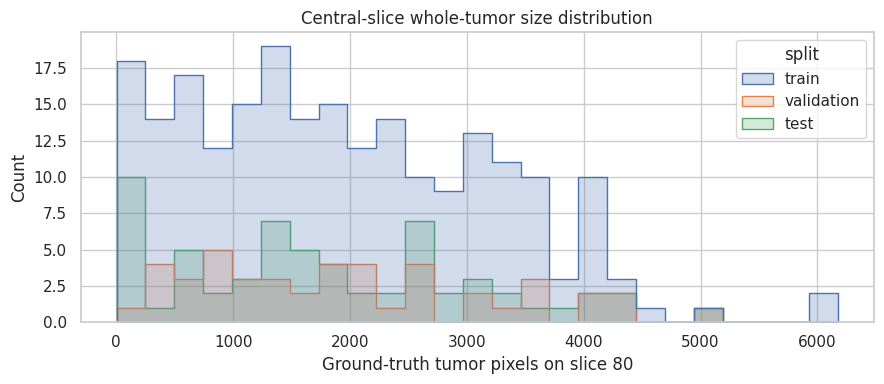

In [3]:
all_split_data = pd.concat([
    pd.read_csv(SPLITS_DIR / f"{name}_ids.csv").assign(split=name)
    for name in ("train", "validation", "test")
], ignore_index=True)
plt.figure(figsize=(9, 4))
sns.histplot(data=all_split_data[all_split_data["tumor_pixels"] > 0], x="tumor_pixels", hue="split", bins=25, element="step", common_norm=False)
plt.title("Central-slice whole-tumor size distribution")
plt.xlabel("Ground-truth tumor pixels on slice 80")
plt.tight_layout()
plt.show()

## 3. MRI-specific preprocessing

Every modality is Z-score normalized using only nonzero brain pixels from the same central slice. Relative distance and bilateral symmetry are also calculated only on this 2D slice.

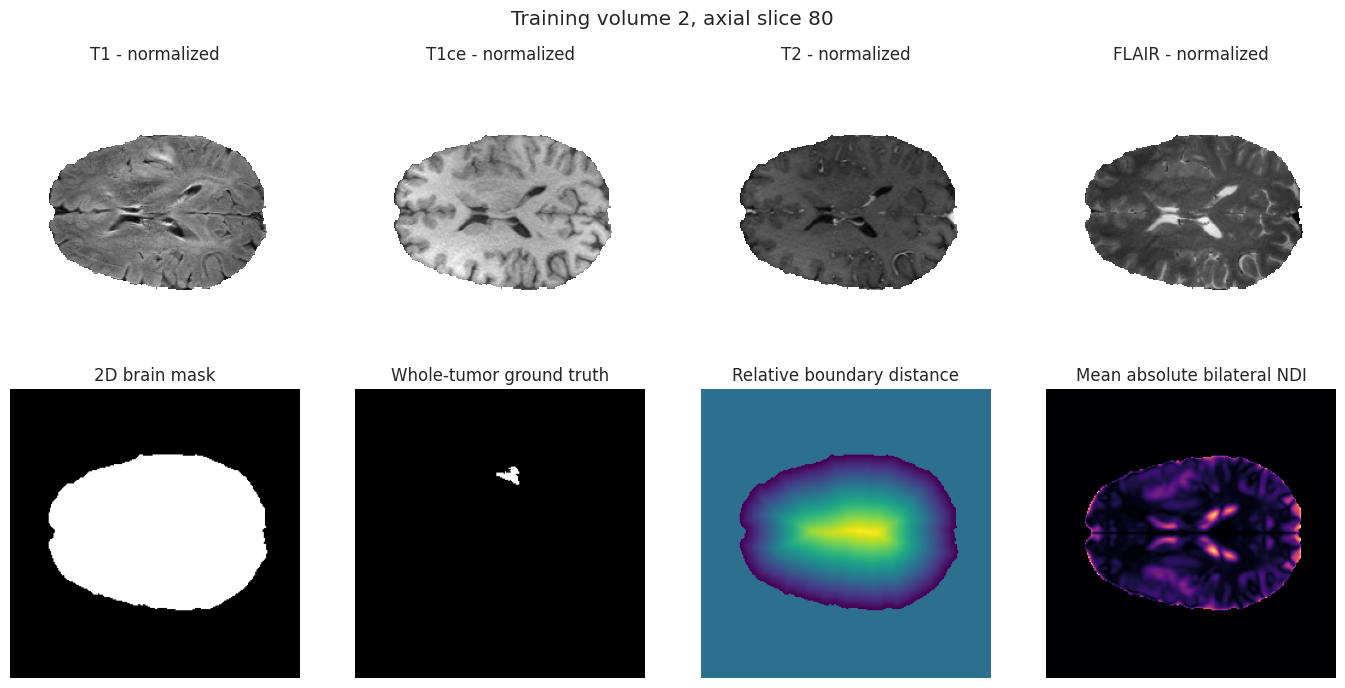

In [4]:
train_manifest = pd.read_csv(SPLITS_DIR / "train_ids.csv")
sample_volume = int(train_manifest.loc[train_manifest["tumor_pixels"] > 0, "volume_id"].iloc[0])
sample = load_preprocessed_slice(sample_volume)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for index, name in enumerate(MODALITY_NAMES):
    axes.flat[index].imshow(np.where(sample.brain_mask, sample.image[..., index], np.nan), cmap="gray")
    axes.flat[index].set_title(f"{name} - normalized")
axes.flat[4].imshow(sample.brain_mask, cmap="gray")
axes.flat[4].set_title("2D brain mask")
axes.flat[5].imshow(sample.whole_tumor, cmap="gray")
axes.flat[5].set_title("Whole-tumor ground truth")
axes.flat[6].imshow(sample.distance, cmap="viridis")
axes.flat[6].set_title("Relative boundary distance")
axes.flat[7].imshow(np.mean(np.abs(sample.symmetry), axis=-1), cmap="magma")
axes.flat[7].set_title("Mean absolute bilateral NDI")
for axis in axes.flat:
    axis.axis("off")
fig.suptitle(f"Training volume {sample_volume}, axial slice {SLICE_NUM}")
plt.tight_layout()
plt.show()

## 4. Statistical and image-processing pipelines

### Baseline

`4 MRI modalities -> patient-balanced sampling -> class GMMs -> stable log-sum-exp posterior -> posterior components -> information-theoretic classification -> seed expansion`

### Proposed model

`boundary GMM posterior + symmetry GMM posterior -> weighted probability fusion -> hierarchical confirmation of ambiguous components and FLAIR/T2-guided expansion -> frozen image-processing pipeline`

The hierarchy cannot remove a component with strong boundary-symmetry support. It confirms ambiguous components and guides connected expansion using FLAIR/T2 evidence. Sobel edges are retained as a diagnostic, but a candidate does not require a perfectly closed edge.

## 5. Model training

Healthy samples are selected randomly and approximately evenly across training patients. Tumor samples are capped per patient and tissue class so large tumors do not dominate. Selection models are trained on the training split. After all parameters are frozen, separate final models are fitted on train + validation and used only for the final test evaluation.

In [5]:
models = train_or_load_models(
    splits["train"],
    force=FORCE_RETRAIN_MODELS,
    artifact_scope="selection",
)
model_table = pd.DataFrame([
    {"Model": "Raw (4D)", "Features": "T1, T1ce, T2, FLAIR", "Role": "Baseline"},
    {"Model": "Boundary distance (5D)", "Features": "MRI + relative distance", "Role": "Advanced 1"},
    {"Model": "Symmetry (8D)", "Features": "MRI + four bilateral NDI channels", "Role": "Advanced 2"},
    {"Model": "Boundary + Symmetry", "Features": "Weighted fusion of separate 5D and 8D GMM probabilities", "Role": "Advanced 3"},
    {"Model": "Combined", "Features": "Boundary-symmetry fusion + component confirmation and FLAIR/T2-guided expansion", "Role": "Final proposed model"},
])
display(model_table)

,Model,Features,Role
0,Raw (4D),"T1, T1ce, T2, FLAIR",Baseline
1,Boundary distance (5D),MRI + relative distance,Advanced 1
2,Symmetry (8D),MRI + four bilateral NDI channels,Advanced 2
3,Boundary + Symmetry,Weighted fusion of separate 5D and 8D GMM prob...,Advanced 3
4,Combined,Boundary-symmetry fusion + component confirmat...,Final proposed model


## 6. Baseline validation optimization and parameter freezing

The baseline jointly selects image-processing and probabilistic parameters with a reduced search. After this cell completes, the image-processing parameters and segmentation thresholds are frozen for every advanced model.

In [6]:
if REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists():
    selected = load_selected_parameters()
    frozen_image_params = selected["frozen_image_processing_params"]
    model_probability_params = selected["model_probability_params"]
    optimization_studies = {}
else:
    frozen_image_params, baseline_probability_params, baseline_study, baseline_trial = optimize_baseline(
        models["Raw (4D)"], splits["validation"], n_trials=N_BASELINE_TRIALS
    )
    model_probability_params = {"Raw (4D)": baseline_probability_params}
    optimization_studies = {"Raw (4D)": baseline_study}

print("Frozen image-processing parameters:")
display(pd.DataFrame([frozen_image_params]))
print("Baseline probabilistic parameters:")
display(pd.DataFrame([model_probability_params["Raw (4D)"]]))

[I 2026-08-25 19:21:15,522] A new study created in memory with name: no-name-bfd9fa8c-946f-4286-81df-45cc5cda1a74
Best trial: 0. Best value: 0.7098:   3%|▎         | 1/30 [00:01<00:39,  1.37s/it]

[I 2026-08-25 19:21:16,890] Trial 0 finished with value: 0.7097997866760934 and parameters: {'min_component_size': 50, 'small_min_component_size': 8, 'closing_size': 3, 'max_expansion_distance': 40, 'log_odds_offset': 0.0, 'temperature': 1.0, 'candidate_threshold': 0.2, 'component_threshold': 0.5, 'small_component_q95_threshold': 0.85, 'slice_gate_threshold': 0.62, 'entropy_expansion_threshold': 0.1, 'posterior_expansion_threshold': 0.1}. Best is trial 0 with value: 0.7097997866760934.


Best trial: 0. Best value: 0.7098:   7%|▋         | 2/30 [00:01<00:24,  1.15it/s]

[I 2026-08-25 19:21:17,416] Trial 1 finished with value: 0.10382331643736423 and parameters: {'min_component_size': 49, 'small_min_component_size': 24, 'closing_size': 1, 'max_expansion_distance': 26, 'log_odds_offset': -2.6514983269908035, 'temperature': 1.3929409166199482, 'candidate_threshold': 0.34044600469728353, 'component_threshold': 0.6332290311184181, 'small_component_q95_threshold': 0.7057636584028246, 'slice_gate_threshold': 0.839468448256698, 'entropy_expansion_threshold': 0.2997327922401265, 'posterior_expansion_threshold': 0.11370173320348284}. Best is trial 0 with value: 0.7097997866760934.


Best trial: 0. Best value: 0.7098:  10%|█         | 3/30 [00:03<00:30,  1.14s/it]

...

Best trial: 11. Best value: 0.712744: 100%|██████████| 30/30 [00:42<00:00,  1.41s/it]

[I 2026-08-25 19:21:57,791] Trial 29 finished with value: 0.4191300887671594 and parameters: {'min_component_size': 48, 'small_min_component_size': 12, 'closing_size': 5, 'max_expansion_distance': 43, 'log_odds_offset': -1.5674616654266953, 'temperature': 0.7561546496792932, 'candidate_threshold': 0.34008874624598084, 'component_threshold': 0.46575796307984907, 'small_component_q95_threshold': 0.7327650603498053, 'slice_gate_threshold': 0.8359391429719839, 'entropy_expansion_threshold': 0.30507881860604086, 'posterior_expansion_threshold': 0.11187156085383207}. Best is trial 11 with value: 0.7127438380776764.
Frozen image-processing parameters:


,small_min_component_size,max_expansion_distance,closing_size,min_component_size
0,8,40,3,50


Baseline probabilistic parameters:


,log_odds_offset,temperature,candidate_threshold,component_threshold,small_component_q95_threshold,slice_gate_threshold,entropy_expansion_threshold,posterior_expansion_threshold
0,0.0,1.0,0.2,0.5,0.85,0.62,0.1,0.1


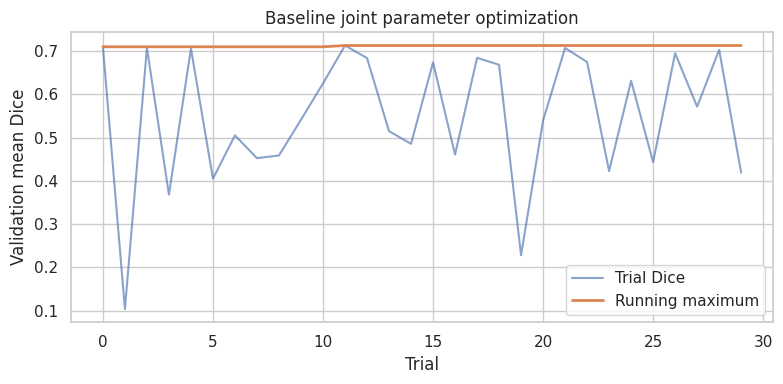

In [7]:
if "Raw (4D)" in optimization_studies:
    history = optimization_studies["Raw (4D)"].trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running maximum")
    plt.xlabel("Trial")
    plt.ylabel("Validation mean Dice")
    plt.title("Baseline joint parameter optimization")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Advanced-model validation optimization

The frozen baseline image-processing and segmentation parameters are reused without modification. Boundary and Symmetry tune only a calibration offset. Fusion additionally tunes one boundary-versus-symmetry weight; Combined additionally tunes component-confirmation and FLAIR/T2-expansion thresholds.

In [8]:
advanced_names = [
    "Boundary distance (5D)",
    "Symmetry (8D)",
    "Boundary + Symmetry",
    "Combined",
]
if not (REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists()):
    baseline_probability_params = model_probability_params["Raw (4D)"]
    for index, model_name in enumerate(advanced_names, start=1):
        probability_params, study, selected_trial = optimize_advanced_model(
            models[model_name],
            splits["validation"],
            frozen_image_params,
            baseline_probability_params,
            n_trials=N_ADVANCED_TRIALS,
            seed=RANDOM_SEED + index,
        )
        model_probability_params[model_name] = probability_params
        optimization_studies[model_name] = study

validation_results = {}
for model_name, model in models.items():
    result = evaluate_model(
        model,
        splits["validation"],
        frozen_image_params,
        model_probability_params[model_name],
    )
    validation_results[model_name] = result

validation_summary = pd.DataFrame([
    result["summary"] for result in validation_results.values()
])
display(validation_summary.round(4))

if not (REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists()):
    selected = save_selected_parameters(
        frozen_image_params,
        model_probability_params,
        {row["model"]: row for row in validation_summary.to_dict("records")},
    )

[I 2026-08-25 19:22:01,093] A new study created in memory with name: no-name-451f80a9-38ff-4583-a5e7-3a1da2b7b618
Best trial: 0. Best value: 0.739961:   5%|▌         | 1/20 [00:01<00:28,  1.48s/it]

[I 2026-08-25 19:22:02,571] Trial 0 finished with value: 0.7399614332527291 and parameters: {'log_odds_offset': 0.0}. Best is trial 0 with value: 0.7399614332527291.


Best trial: 0. Best value: 0.739961:  10%|█         | 2/20 [00:02<00:19,  1.11s/it]

[I 2026-08-25 19:22:03,420] Trial 1 finished with value: 0.591517740375986 and parameters: {'log_odds_offset': -2.309672601661326}. Best is trial 0 with value: 0.7399614332527291.


Best trial: 0. Best value: 0.739961:  15%|█▌        | 3/20 [00:04<00:24,  1.43s/it]

...

Best trial: 15. Best value: 0.778984:  95%|█████████▌| 19/20 [00:42<00:02,  2.08s/it]

[I 2026-08-25 19:24:38,122] Trial 18 finished with value: 0.7076584522208574 and parameters: {'log_odds_offset': -2.117946978530564, 'fusion_weight': 0.3545452669707362, 'hierarchy_confirmation_threshold': 0.8501249924124948, 'outer_expansion_threshold': 0.9416250284481255}. Best is trial 15 with value: 0.7789842295767224.


Best trial: 15. Best value: 0.778984: 100%|██████████| 20/20 [00:46<00:00,  2.35s/it]


[I 2026-08-25 19:24:42,145] Trial 19 finished with value: 0.4121070486213874 and parameters: {'log_odds_offset': 2.8559285884616923, 'fusion_weight': 0.20945147693979022, 'hierarchy_confirmation_threshold': 0.7656576382678433, 'outer_expansion_threshold': 0.64171338499991}. Best is trial 15 with value: 0.7789842295767224.


,model,dice_mean,dice_std,iou_mean,iou_std,tumor_present_dice,precision,recall,missed_tumors,tumor_slices,empty_slice_false_positives,empty_slices
0,Raw (4D),0.7098,0.3213,0.6271,0.3141,0.7220,0.7037,0.7885,5,45,2,5
1,Boundary distance (5D),0.7490,0.2594,0.6527,0.2651,0.7878,0.7740,0.8703,0,45,3,5
2,Symmetry (8D),0.7224,0.2929,0.6299,0.2860,0.7804,0.7631,0.8621,1,45,4,5
3,Boundary + Symmetry,0.7874,0.2457,0.6999,0.2552,0.8082,0.7916,0.8753,1,45,2,5
4,Combined,0.7790,0.2491,0.6899,0.2603,0.7989,0.7786,0.8743,1,45,2,5


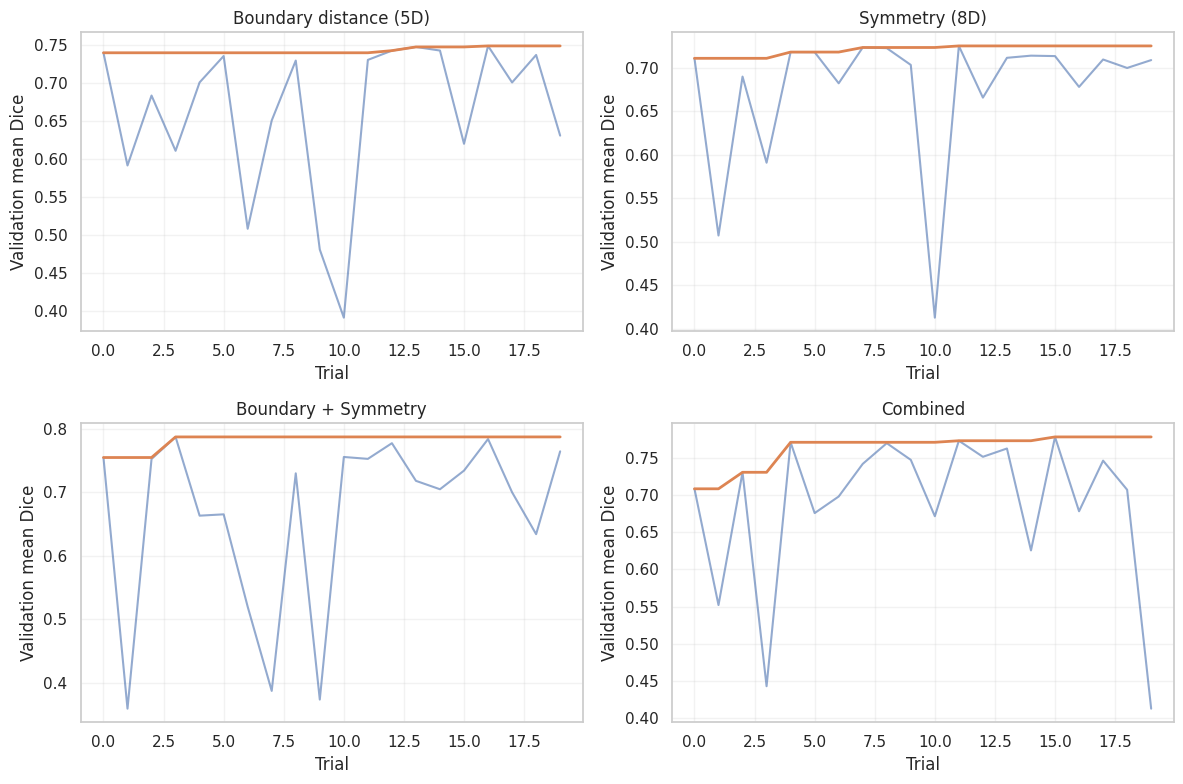

,Model,log_odds_offset,temperature,candidate_threshold,component_threshold,small_component_q95_threshold,slice_gate_threshold,entropy_expansion_threshold,posterior_expansion_threshold,fusion_weight,hierarchy_confirmation_threshold,outer_expansion_threshold
0,Raw (4D),0.0000,1.0,0.2,0.5,0.85,0.62,0.1,0.1,NaN,NaN,NaN
1,Boundary distance (5D),-0.2991,1.0,0.2,0.5,0.85,0.62,0.1,0.1,NaN,NaN,NaN
2,Symmetry (8D),-0.5456,1.0,0.2,0.5,0.85,0.62,0.1,0.1,NaN,NaN,NaN
3,Boundary + Symmetry,-0.3332,1.0,0.2,0.5,0.85,0.62,0.1,0.1,0.4782,NaN,NaN
4,Combined,-0.6837,1.0,0.2,0.5,0.85,0.62,0.1,0.1,0.3223,0.8948,0.639


In [9]:
if optimization_studies:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for axis, model_name in zip(axes.flat, advanced_names):
        history = optimization_studies[model_name].trials_dataframe()
        axis.plot(history["number"], history["value"], alpha=0.6)
        axis.plot(history["number"], history["value"].cummax(), linewidth=2)
        axis.set_title(model_name)
        axis.set_xlabel("Trial")
        axis.set_ylabel("Validation mean Dice")
        axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

parameter_rows = []
for model_name, parameters in model_probability_params.items():
    parameter_rows.append({"Model": model_name, **parameters})
display(pd.DataFrame(parameter_rows).round(4))

## 8. Validation posterior inspection

This inspection compares the probability evidence before the test set is evaluated.

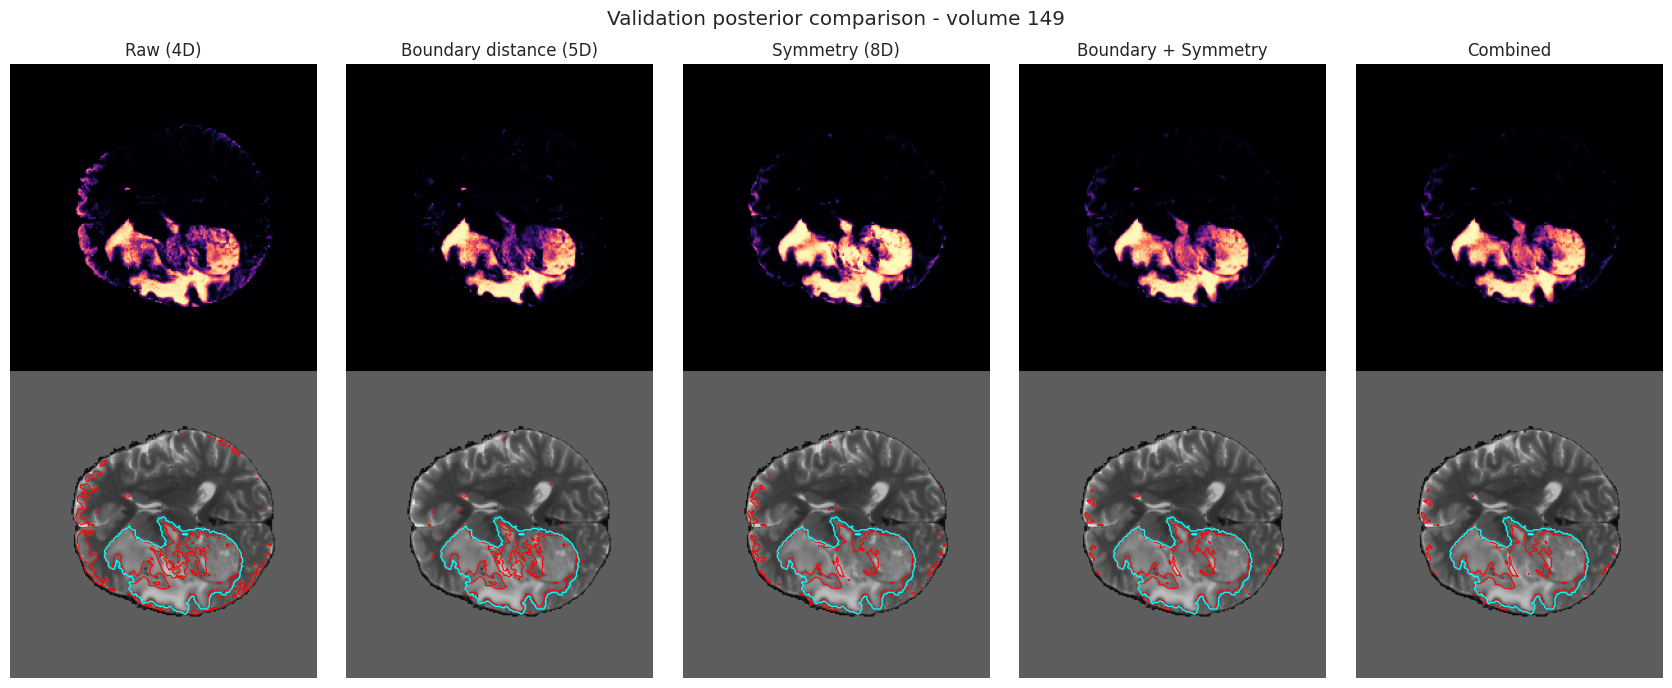

In [10]:
inspection_volume = int(pd.read_csv(SPLITS_DIR / "validation_ids.csv").sort_values("tumor_pixels", ascending=False)["volume_id"].iloc[0])
inspection_data = load_preprocessed_slice(inspection_volume)
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for column, model_name in enumerate(MODEL_NAMES):
    evidence = models[model_name].prepare(inspection_data)
    posterior = models[model_name].posteriors_from_evidence(evidence, model_probability_params[model_name])
    tumor_probability = posterior[..., 1:].sum(axis=-1)
    axes[0, column].imshow(tumor_probability, cmap="magma", vmin=0, vmax=1)
    axes[0, column].set_title(model_name)
    axes[1, column].imshow(inspection_data.image[..., 3], cmap="gray")
    axes[1, column].contour(tumor_probability, levels=[model_probability_params[model_name]["candidate_threshold"]], colors="red", linewidths=0.8)
    axes[1, column].contour(inspection_data.whole_tumor, levels=[0.5], colors="cyan", linewidths=1)
    axes[0, column].axis("off")
    axes[1, column].axis("off")
axes[0, 0].set_ylabel("Tumor posterior")
axes[1, 0].set_ylabel("FLAIR: red candidate, cyan GT")
fig.suptitle(f"Validation posterior comparison - volume {inspection_volume}")
plt.tight_layout()
plt.show()

## 9. Final train + validation fit and locked test evaluation

All image-processing and probabilistic parameters are frozen. The GMMs are now refitted using the combined train + validation development set, and the resulting models are evaluated on the test set without further parameter selection.

In [11]:
development_ids = np.concatenate([
    splits["train"],
    splits["validation"],
])
final_models = train_or_load_models(
    development_ids,
    force=FORCE_RETRAIN_MODELS,
    artifact_scope="final",
)

TEST_RESULTS = {}
for model_name, model in final_models.items():
    result = evaluate_model(
        model,
        splits["test"],
        frozen_image_params,
        model_probability_params[model_name],
        return_details=True,
    )
    TEST_RESULTS[model_name] = result
    save_evaluation(
        result,
        TEST_OUTPUT_DIR,
        model_name.lower().replace(" ", "_").replace("(", "").replace(")", ""),
    )

test_summary = pd.DataFrame([
    result["summary"] for result in TEST_RESULTS.values()
])
test_summary["Missed tumors"] = (
    test_summary["missed_tumors"].astype(str)
    + "/"
    + test_summary["tumor_slices"].astype(str)
)
test_summary["Empty-slice FP"] = (
    test_summary["empty_slice_false_positives"].astype(str)
    + "/"
    + test_summary["empty_slices"].astype(str)
)
display(test_summary[[
    "model", "dice_mean", "dice_std", "tumor_present_dice", "precision", "recall",
    "iou_mean", "iou_std", "Missed tumors", "Empty-slice FP",
]].round(4))

,model,dice_mean,dice_std,tumor_present_dice,precision,recall,iou_mean,iou_std,Missed tumors,Empty-slice FP
0,Raw (4D),0.6846,0.3537,0.7135,0.6973,0.7858,0.6114,0.3424,7/62,4/7
1,Boundary distance (5D),0.6900,0.3428,0.7356,0.7323,0.7898,0.6116,0.3283,5/62,5/7
2,Symmetry (8D),0.6635,0.3581,0.7223,0.7266,0.7806,0.5862,0.3383,6/62,6/7
3,Boundary + Symmetry,0.6899,0.3602,0.7356,0.7248,0.7902,0.6203,0.3439,8/62,5/7
4,Combined,0.6868,0.3484,0.7482,0.7395,0.8137,0.6107,0.3339,5/62,6/7


### Required baseline-versus-proposed table

The course requires the mean and standard deviation of Dice and IoU for the baseline and final proposed model.

In [12]:
required_table = test_summary[test_summary["model"].isin(["Raw (4D)", "Combined"])][[
    "model", "dice_mean", "dice_std", "iou_mean", "iou_std"
]].rename(columns={
    "model": "Model", "dice_mean": "Dice mean", "dice_std": "Dice std",
    "iou_mean": "IoU mean", "iou_std": "IoU std",
})
display(required_table.round(4))

,Model,Dice mean,Dice std,IoU mean,IoU std
0,Raw (4D),0.6846,0.3537,0.6114,0.3424
4,Combined,0.6868,0.3484,0.6107,0.3339


### Required Dice and IoU boxplots

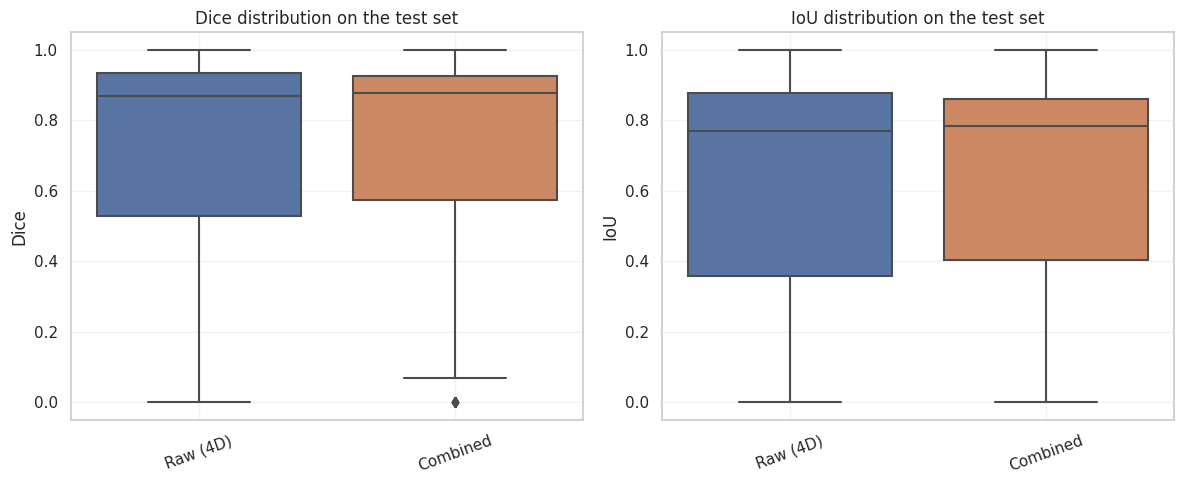

In [13]:
required_frames = [
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
]
plot_metric_boxplots(required_frames, FIGURES_DIR / "required_dice_iou_boxplots.png")
plt.show()

### Five-model ablation boxplots

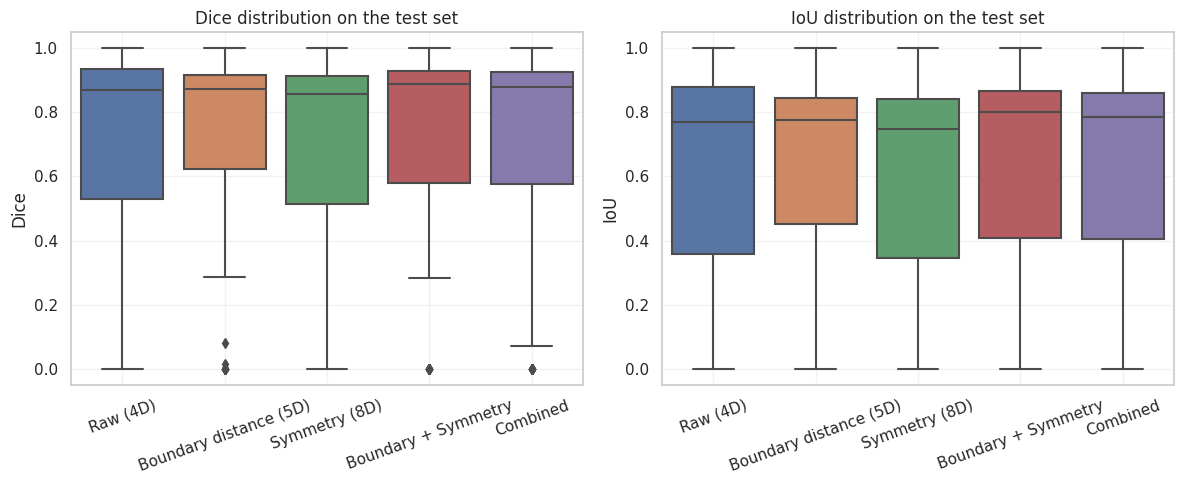

In [14]:
plot_metric_boxplots(
    [TEST_RESULTS[name]["per_volume"] for name in MODEL_NAMES],
    FIGURES_DIR / "all_models_dice_iou_boxplots.png",
)
plt.show()

### Required patient-level scatterplots

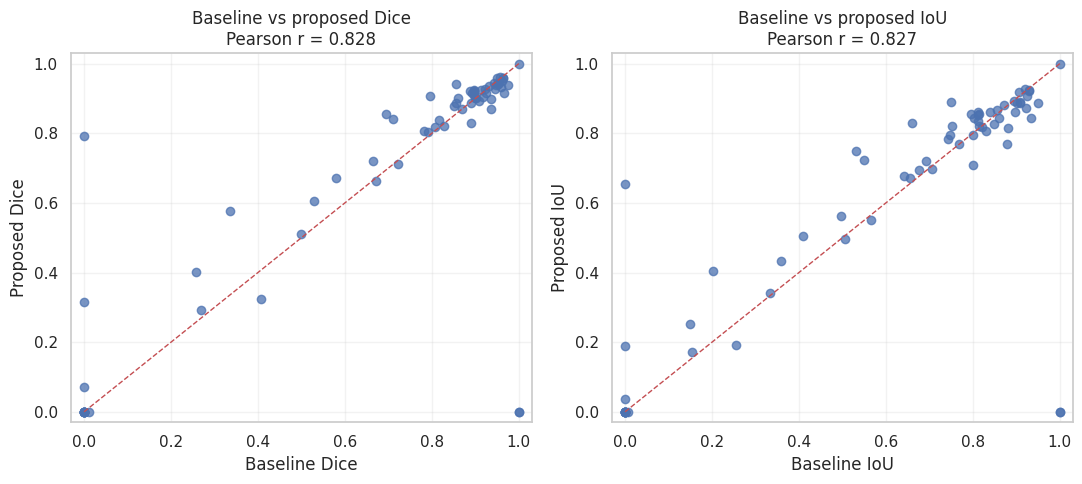

In [15]:
plot_required_scatterplots(
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
    FIGURES_DIR / "required_baseline_proposed_scatterplots.png",
)
plt.show()

### Additional paired baseline-versus-advanced scatterplots

These plots preserve the complete paired-model inspection from the original project notebook.

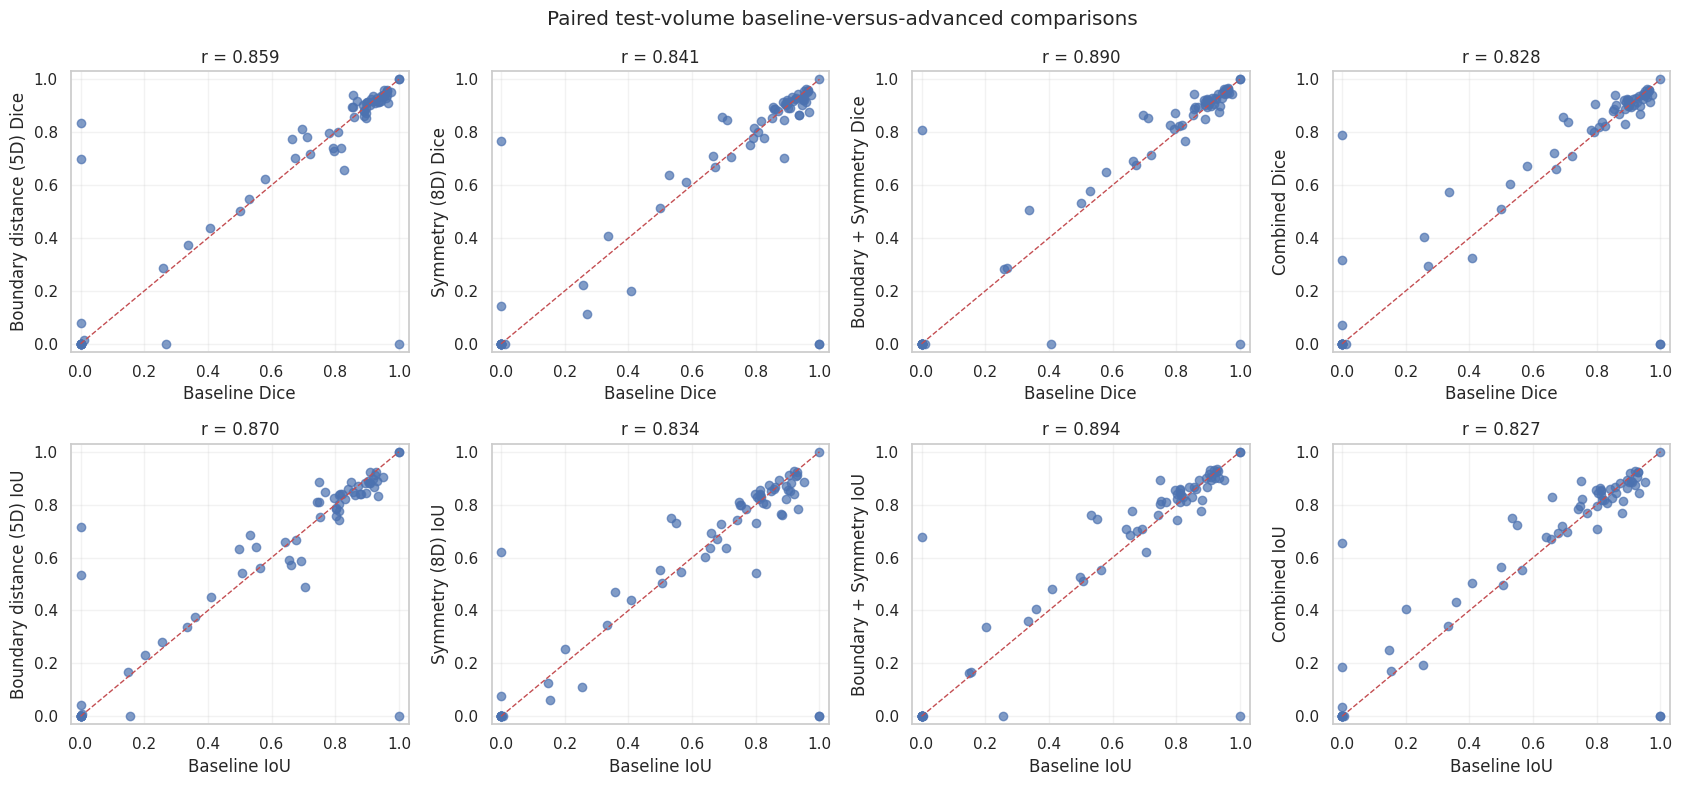

In [16]:
advanced_names_for_plot = [name for name in MODEL_NAMES if name != "Raw (4D)"]
fig, axes = plt.subplots(2, len(advanced_names_for_plot), figsize=(17, 8))
baseline_frame = TEST_RESULTS["Raw (4D)"]["per_volume"]
for column, model_name in enumerate(advanced_names_for_plot):
    advanced_frame = TEST_RESULTS[model_name]["per_volume"]
    merged = baseline_frame.merge(advanced_frame, on="volume_id", suffixes=("_baseline", "_advanced"))
    for row, (metric, label) in enumerate((("dice", "Dice"), ("iou", "IoU"))):
        x = merged[f"{metric}_baseline"]
        y = merged[f"{metric}_advanced"]
        correlation = np.corrcoef(x, y)[0, 1]
        axes[row, column].scatter(x, y, alpha=0.7)
        axes[row, column].plot([0, 1], [0, 1], "r--", linewidth=1)
        axes[row, column].set(
            xlim=(-0.03, 1.03), ylim=(-0.03, 1.03),
            xlabel=f"Baseline {label}", ylabel=f"{model_name} {label}",
            title=f"r = {correlation:.3f}",
        )
        axes[row, column].grid(alpha=0.25)
fig.suptitle("Paired test-volume baseline-versus-advanced comparisons")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "all_paired_model_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Failure analysis and additional diagnostics

In [17]:
per_volume_comparison = pd.DataFrame({"volume_id": splits["test"]})
for model_name in MODEL_NAMES:
    frame = TEST_RESULTS[model_name]["per_volume"]
    per_volume_comparison = per_volume_comparison.merge(
        frame[["volume_id", "dice", "iou", "precision", "recall", "ground_truth_size", "prediction_size"]].rename(columns={
            column: f"{model_name} {column}" for column in frame.columns if column != "volume_id"
        }),
        on="volume_id",
    )
display(per_volume_comparison.round(4))
per_volume_comparison.to_csv(TEST_OUTPUT_DIR / "all_models_per_volume.csv", index=False)

,volume_id,Raw (4D) dice,Raw (4D) iou,Raw (4D) precision,Raw (4D) recall,Raw (4D) ground_truth_size,Raw (4D) prediction_size,Boundary distance (5D) dice,Boundary distance (5D) iou,Boundary distance (5D) precision,...,Boundary + Symmetry precision,Boundary + Symmetry recall,Boundary + Symmetry ground_truth_size,Boundary + Symmetry prediction_size,Combined dice,Combined iou,Combined precision,Combined recall,Combined ground_truth_size,Combined prediction_size
0,1,0.9226,0.8563,0.9541,0.8931,4217,3947,0.9167,0.8462,0.9734,...,0.9503,0.9073,4217,4026,0.9280,0.8657,0.9523,0.9049,4217,4007
1,3,0.5282,0.3589,0.3597,0.9941,678,1874,0.5473,0.3768,0.3802,...,0.4107,0.9808,678,1619,0.6046,0.4333,0.4358,0.9867,678,1535
2,4,0.9483,0.9017,0.9413,0.9554,2536,2574,0.9413,0.8891,0.9535,...,0.9335,0.9803,2536,2663,0.9397,0.8862,0.9029,0.9795,2536,2751
3,6,0.8958,0.8112,0.8878,0.9039,2591,2638,0.9103,0.8353,0.9392,...,0.9469,0.9020,2591,2468,0.9254,0.8612,0.9575,0.8954,2591,2423
4,7,0.3364,0.2022,0.2022,1.0000,235,1162,0.3739,0.2299,0.2299,...,0.3391,1.0000,235,693,0.5753,0.4038,0.4038,1.0000,235,582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,324,0.8867,0.7965,0.8010,0.9930,1293,1603,0.9038,0.8244,0.8330,...,0.8581,0.9961,1293,1501,0.9211,0.8538,0.8584,0.9938,1293,1497
65,334,0.9450,0.8957,0.9499,0.9401,3088,3056,0.9166,0.8460,0.9516,...,0.9527,0.9064,3088,2938,0.9261,0.8624,0.9527,0.9009,3088,2920
66,347,0.8565,0.7490,0.7628,0.9764,1143,1463,0.9395,0.8859,0.9154,...,0.9078,0.9816,1143,1236,0.9419,0.8902,0.9075,0.9790,1143,1233
67,348,0.9438,0.8935,0.9195,0.9694,1697,1789,0.9368,0.8812,0.9059,...,0.9234,0.9729,1697,1788,0.9429,0.8921,0.9271,0.9593,1697,1756


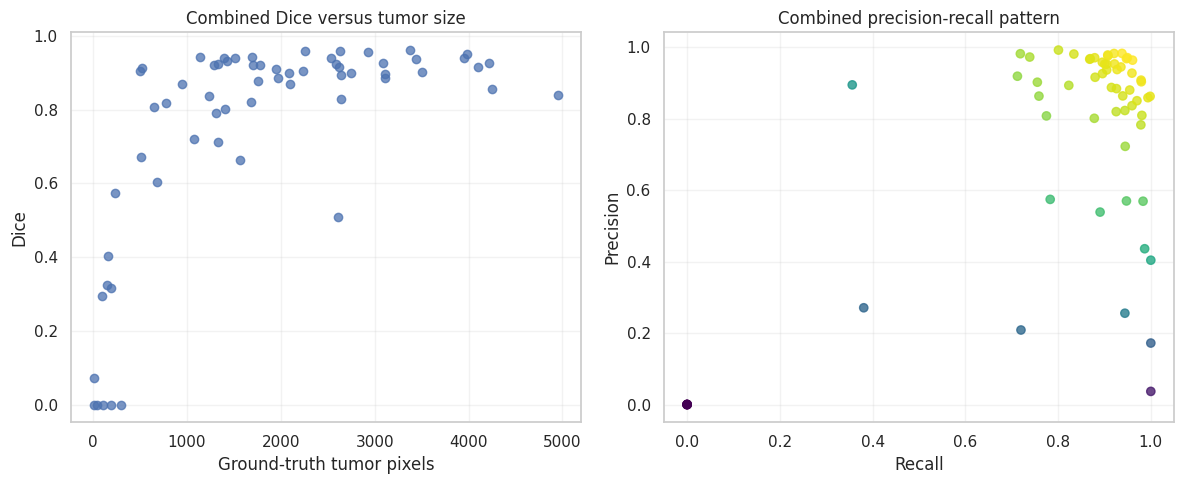

In [18]:
combined_frame = TEST_RESULTS["Combined"]["per_volume"]
tumor_rows = combined_frame[combined_frame["tumor_present"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(tumor_rows["ground_truth_size"], tumor_rows["dice"], alpha=0.75)
axes[0].set(xlabel="Ground-truth tumor pixels", ylabel="Dice", title="Combined Dice versus tumor size")
axes[1].scatter(tumor_rows["recall"], tumor_rows["precision"], c=tumor_rows["dice"], cmap="viridis", alpha=0.8)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Combined precision-recall pattern")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "combined_failure_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
error_case_table = pd.DataFrame([
    {
        "Model": name,
        "Missed tumor volumes": TEST_RESULTS[name]["per_volume"].loc[
            TEST_RESULTS[name]["per_volume"]["missed_tumor"], "volume_id"
        ].astype(int).tolist(),
        "Empty-slice false-positive volumes": TEST_RESULTS[name]["per_volume"].loc[
            TEST_RESULTS[name]["per_volume"]["empty_slice_false_positive"], "volume_id"
        ].astype(int).tolist(),
    }
    for name in MODEL_NAMES
])
display(error_case_table)

,Model,Missed tumor volumes,Empty-slice false-positive volumes
0,Raw (4D),"[19, 89, 102, 157, 188, 206, 283]","[94, 108, 158, 209]"
1,Boundary distance (5D),"[19, 111, 157, 206, 283]","[94, 108, 158, 209, 229]"
2,Symmetry (8D),"[19, 46, 89, 102, 157, 283]","[94, 108, 158, 209, 229, 288]"
3,Boundary + Symmetry,"[19, 46, 89, 102, 157, 206, 227, 283]","[94, 108, 158, 209, 229]"
4,Combined,"[19, 46, 89, 102, 206]","[94, 108, 158, 209, 229, 288]"


### Tumors missed by at least one model

The following paginated error maps preserve the original multi-model missed-tumor inspection. Green denotes true positive, red false positive and blue false negative.

,Volume,GT pixels,Raw (4D) Dice,Boundary distance (5D) Dice,Symmetry (8D) Dice,Boundary + Symmetry Dice,Combined Dice
0,19,107,0.000,0.000,0.000,0.000,0.000
1,46,13,0.012,0.015,0.000,0.000,0.000
2,89,196,0.000,0.697,0.000,0.000,0.000
3,102,40,0.000,0.080,0.000,0.000,0.000
4,111,97,0.268,0.000,0.114,0.287,0.293
5,157,189,0.000,0.000,0.000,0.000,0.316
6,188,1315,0.000,0.835,0.766,0.808,0.791
7,206,294,0.000,0.000,0.144,0.000,0.000
8,227,150,0.407,0.439,0.200,0.000,0.323
9,283,14,0.000,0.000,0.000,0.000,0.071


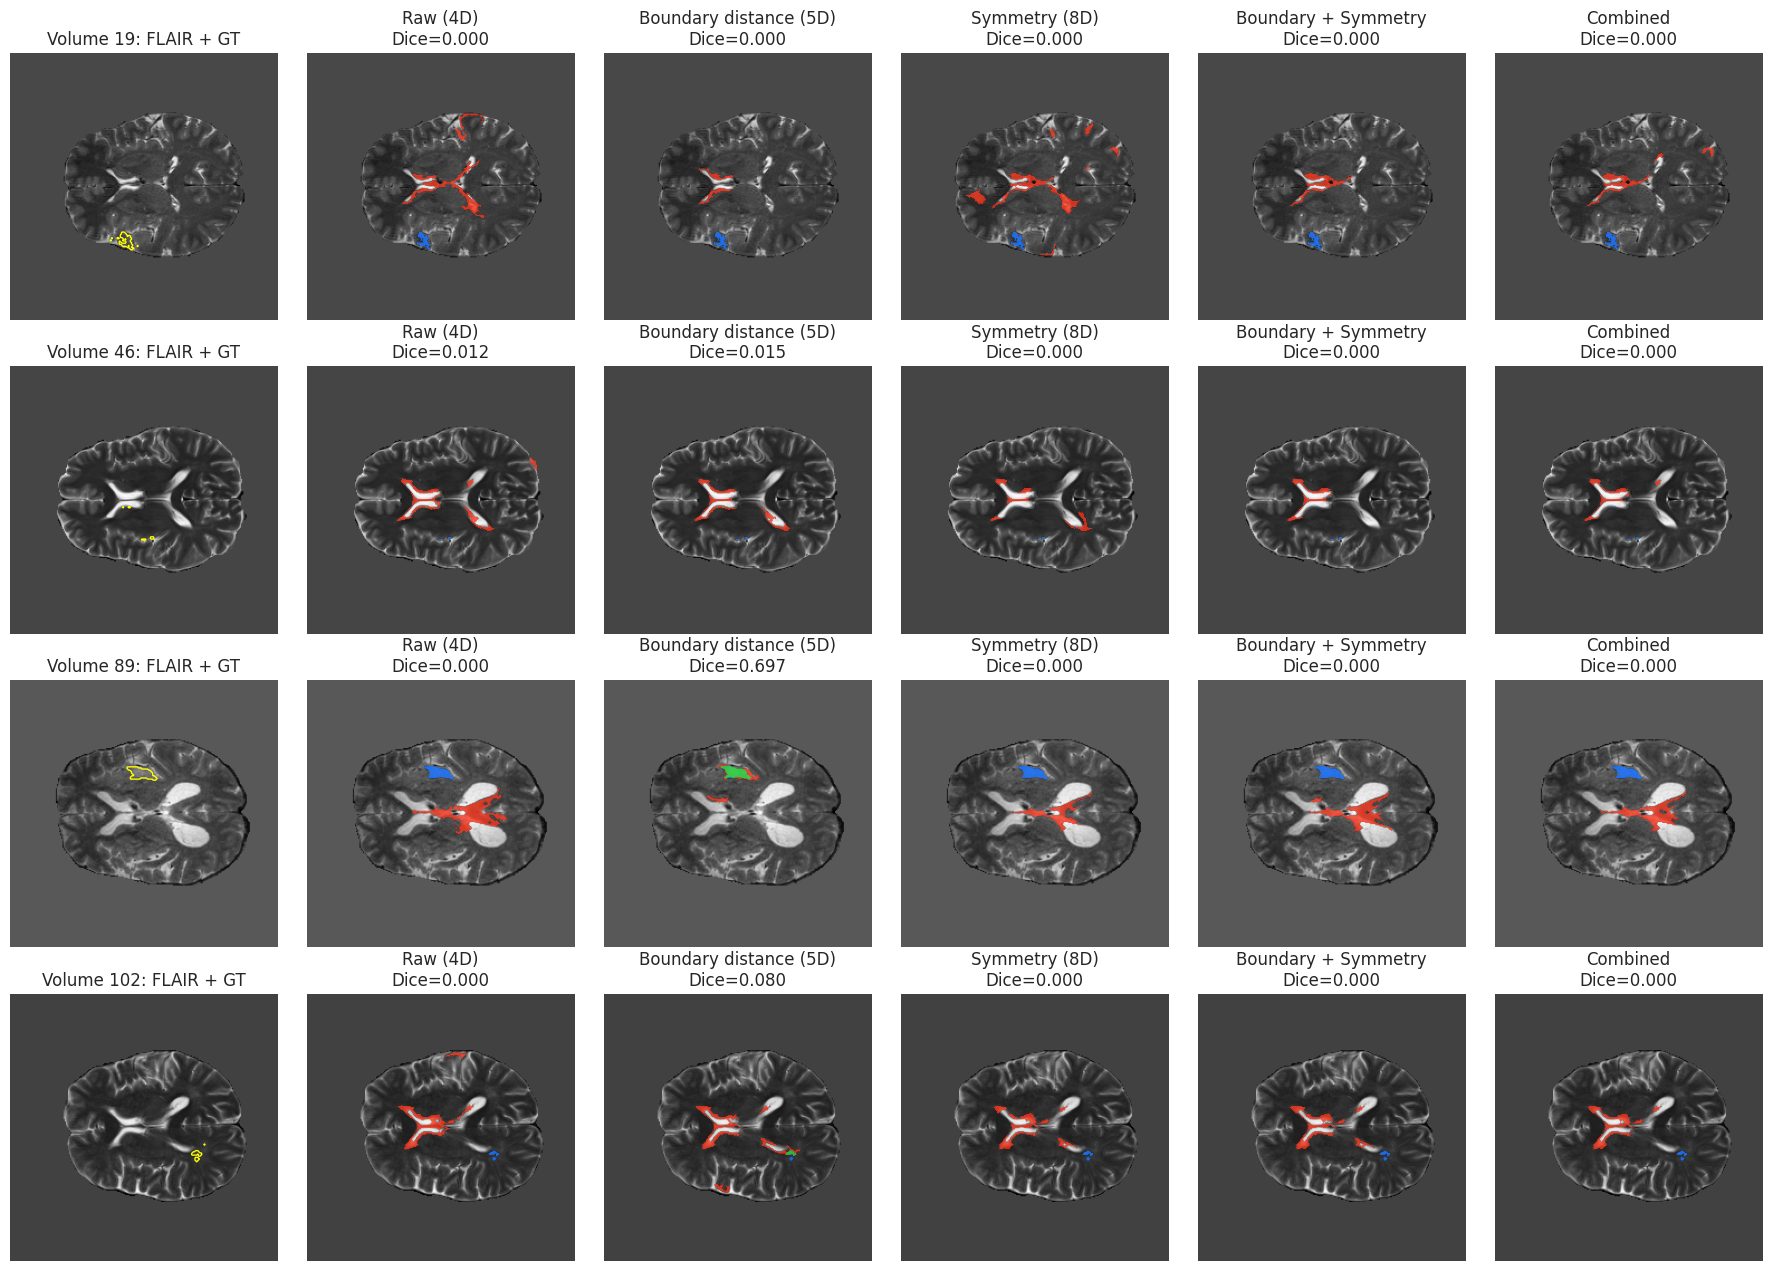

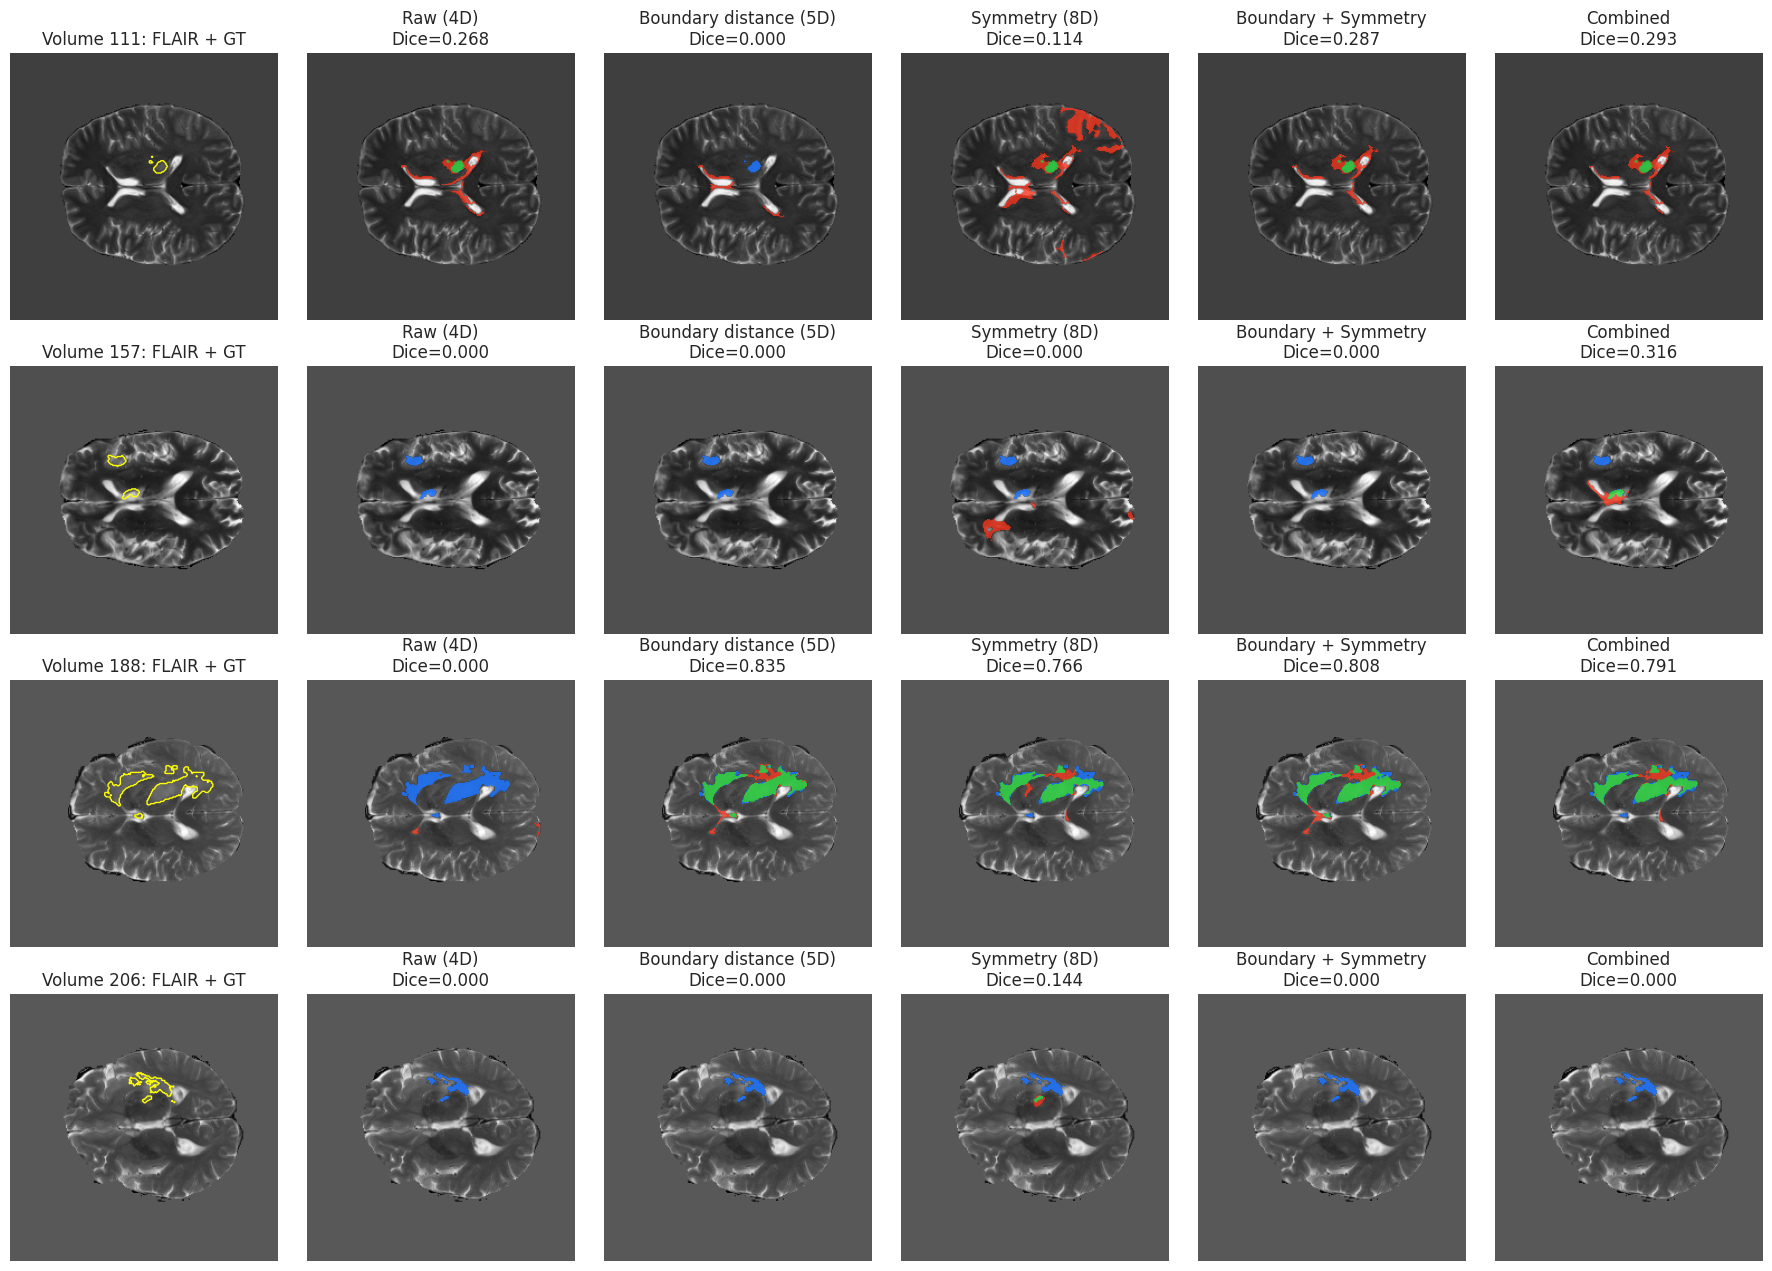

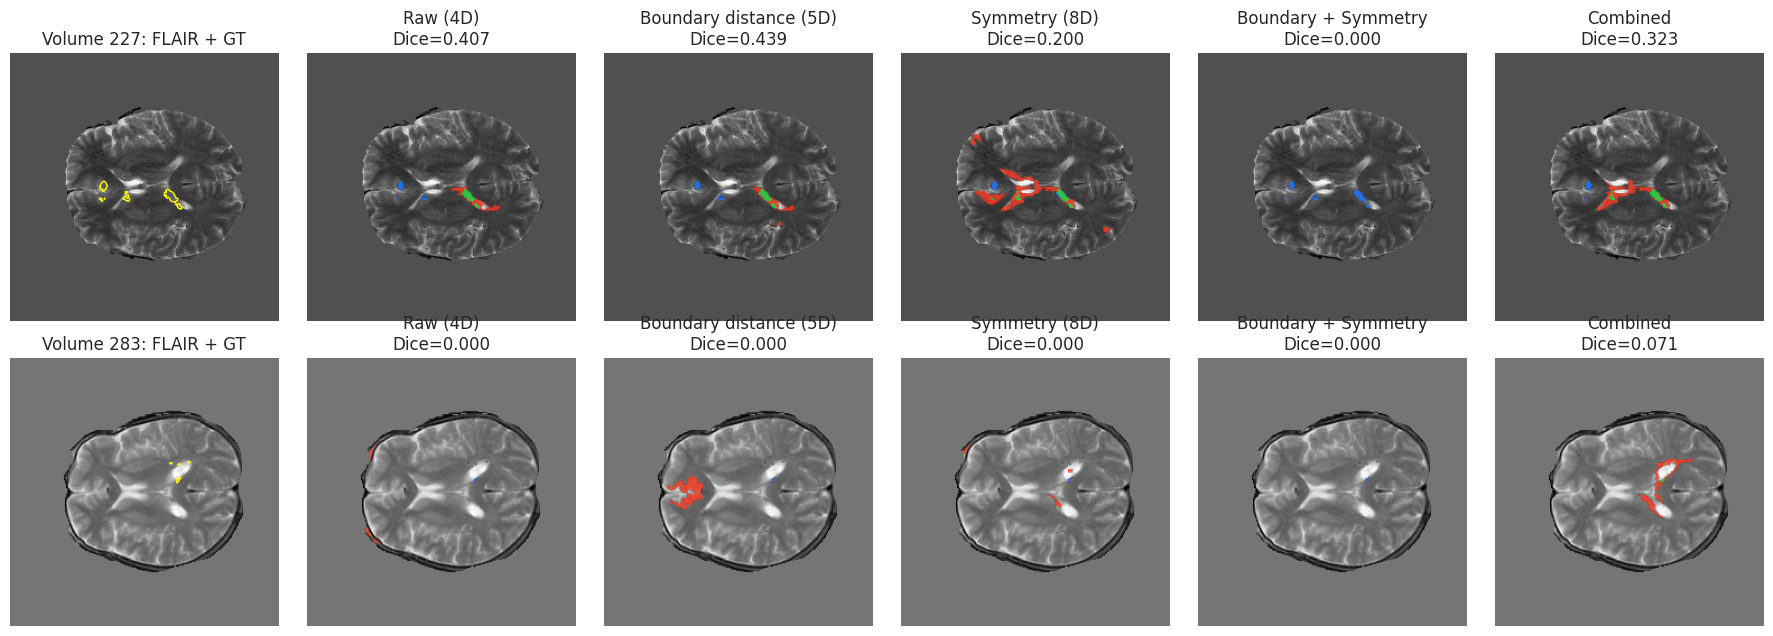

In [20]:
def error_overlay(ground_truth, prediction):
    overlay = np.zeros((*ground_truth.shape, 4), dtype=float)
    overlay[ground_truth & prediction] = (0.15, 0.90, 0.25, 0.75)
    overlay[~ground_truth & prediction] = (1.00, 0.20, 0.10, 0.75)
    overlay[ground_truth & ~prediction] = (0.10, 0.45, 1.00, 0.85)
    return overlay

all_missed_volumes = sorted(set().union(*[
    set(TEST_RESULTS[name]["per_volume"].loc[
        TEST_RESULTS[name]["per_volume"]["missed_tumor"], "volume_id"
    ].astype(int))
    for name in MODEL_NAMES
]))
missed_rows = []
for volume_id in all_missed_volumes:
    row = {"Volume": volume_id, "GT pixels": TEST_RESULTS["Raw (4D)"]["details"][volume_id]["ground_truth_size"]}
    for model_name in MODEL_NAMES:
        row[f"{model_name} Dice"] = TEST_RESULTS[model_name]["details"][volume_id]["dice"]
    missed_rows.append(row)
display(pd.DataFrame(missed_rows).round(3))

rows_per_page = 4
for page, start in enumerate(range(0, len(all_missed_volumes), rows_per_page), start=1):
    page_volumes = all_missed_volumes[start:start + rows_per_page]
    fig, axes = plt.subplots(len(page_volumes), 1 + len(MODEL_NAMES), figsize=(18, 3.2 * len(page_volumes)), squeeze=False)
    for row_index, volume_id in enumerate(page_volumes):
        reference = TEST_RESULTS["Raw (4D)"]["details"][volume_id]
        flair = reference["data"].image[..., 3]
        ground_truth = reference["data"].whole_tumor
        axes[row_index, 0].imshow(flair, cmap="gray")
        if ground_truth.any():
            axes[row_index, 0].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=1)
        axes[row_index, 0].set_title(f"Volume {volume_id}: FLAIR + GT")
        for column, model_name in enumerate(MODEL_NAMES, start=1):
            details = TEST_RESULTS[model_name]["details"][volume_id]
            axes[row_index, column].imshow(flair, cmap="gray")
            axes[row_index, column].imshow(error_overlay(ground_truth, details["prediction"]))
            axes[row_index, column].set_title(f"{model_name}\nDice={details['dice']:.3f}")
        for axis in axes[row_index]:
            axis.axis("off")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"missed_tumor_error_maps_{page}.png", dpi=250, bbox_inches="tight")
    plt.show()

### Complete pipeline trace

This trace verifies whether a poor case fails at the posterior, component-classification, or expansion stage.

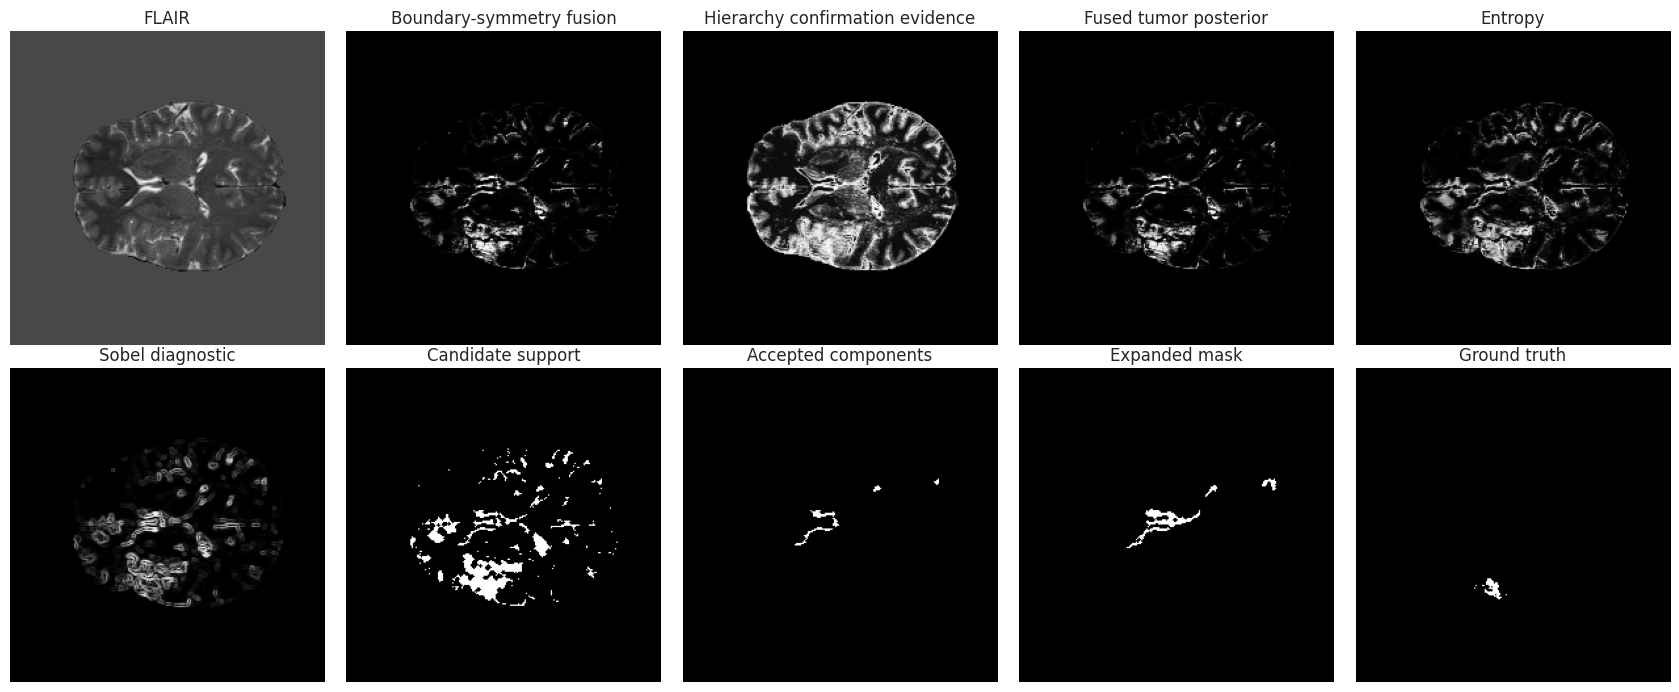

,component,area,weighted_tumor_probability,posterior_q95,base_weighted_probability,standard_size,confident_small_component,protected_by_base_fusion,mean_outer_probability,mean_core_probability,hierarchy_confirmation_score,confirmed_by_hierarchy,slice_gate_score,accepted_before_slice_gate,slice_gate_passed,accepted
0,0,11,0.2904,0.4533,0.2904,False,False,False,0.7566,0.8570,0.7817,False,0.3963,False,True,False
1,1,30,0.4412,0.9538,0.4412,False,True,False,0.6427,0.8422,0.6926,False,0.7744,False,True,False
2,2,20,0.4128,0.6972,0.4128,False,False,False,0.7505,0.8196,0.7678,False,0.5977,False,True,False
3,3,11,0.2770,0.6329,0.2770,False,False,False,0.4030,0.9049,0.5285,False,0.5084,False,True,False
4,4,19,0.3624,0.5237,0.3624,False,False,False,0.7018,0.6834,0.6972,False,0.4672,False,True,False
5,5,26,0.3128,0.5970,0.3128,False,False,False,0.6104,0.9168,0.6870,False,0.4975,False,True,False
6,6,24,0.3132,0.7261,0.3132,False,False,False,0.5005,0.8900,0.5979,False,0.5816,False,True,False
7,7,11,0.5042,0.8602,0.5042,False,True,False,0.7473,0.7310,0.7432,False,0.7356,True,True,True
8,8,17,0.5217,0.9055,0.5217,False,True,False,0.4394,0.9206,0.5597,False,0.7712,True,True,True
9,9,14,0.3780,0.6474,0.3780,False,False,False,0.4404,0.7538,0.5188,False,0.5531,False,True,False


In [21]:
worst_tumor_volume = int(tumor_rows.sort_values("dice").iloc[0]["volume_id"])
worst_details = TEST_RESULTS["Combined"]["details"][worst_tumor_volume]
plot_pipeline_diagnostic(
    worst_details,
    FIGURES_DIR / f"pipeline_trace_volume_{worst_tumor_volume}.png",
)
plt.show()
display(pd.DataFrame(worst_details["component_table"]).round(4))

### Required four qualitative examples

,Required category,Volume
0,Both performed well,162
1,Both performed poorly,102
2,Baseline performed better,227
3,Proposed model performed better,188


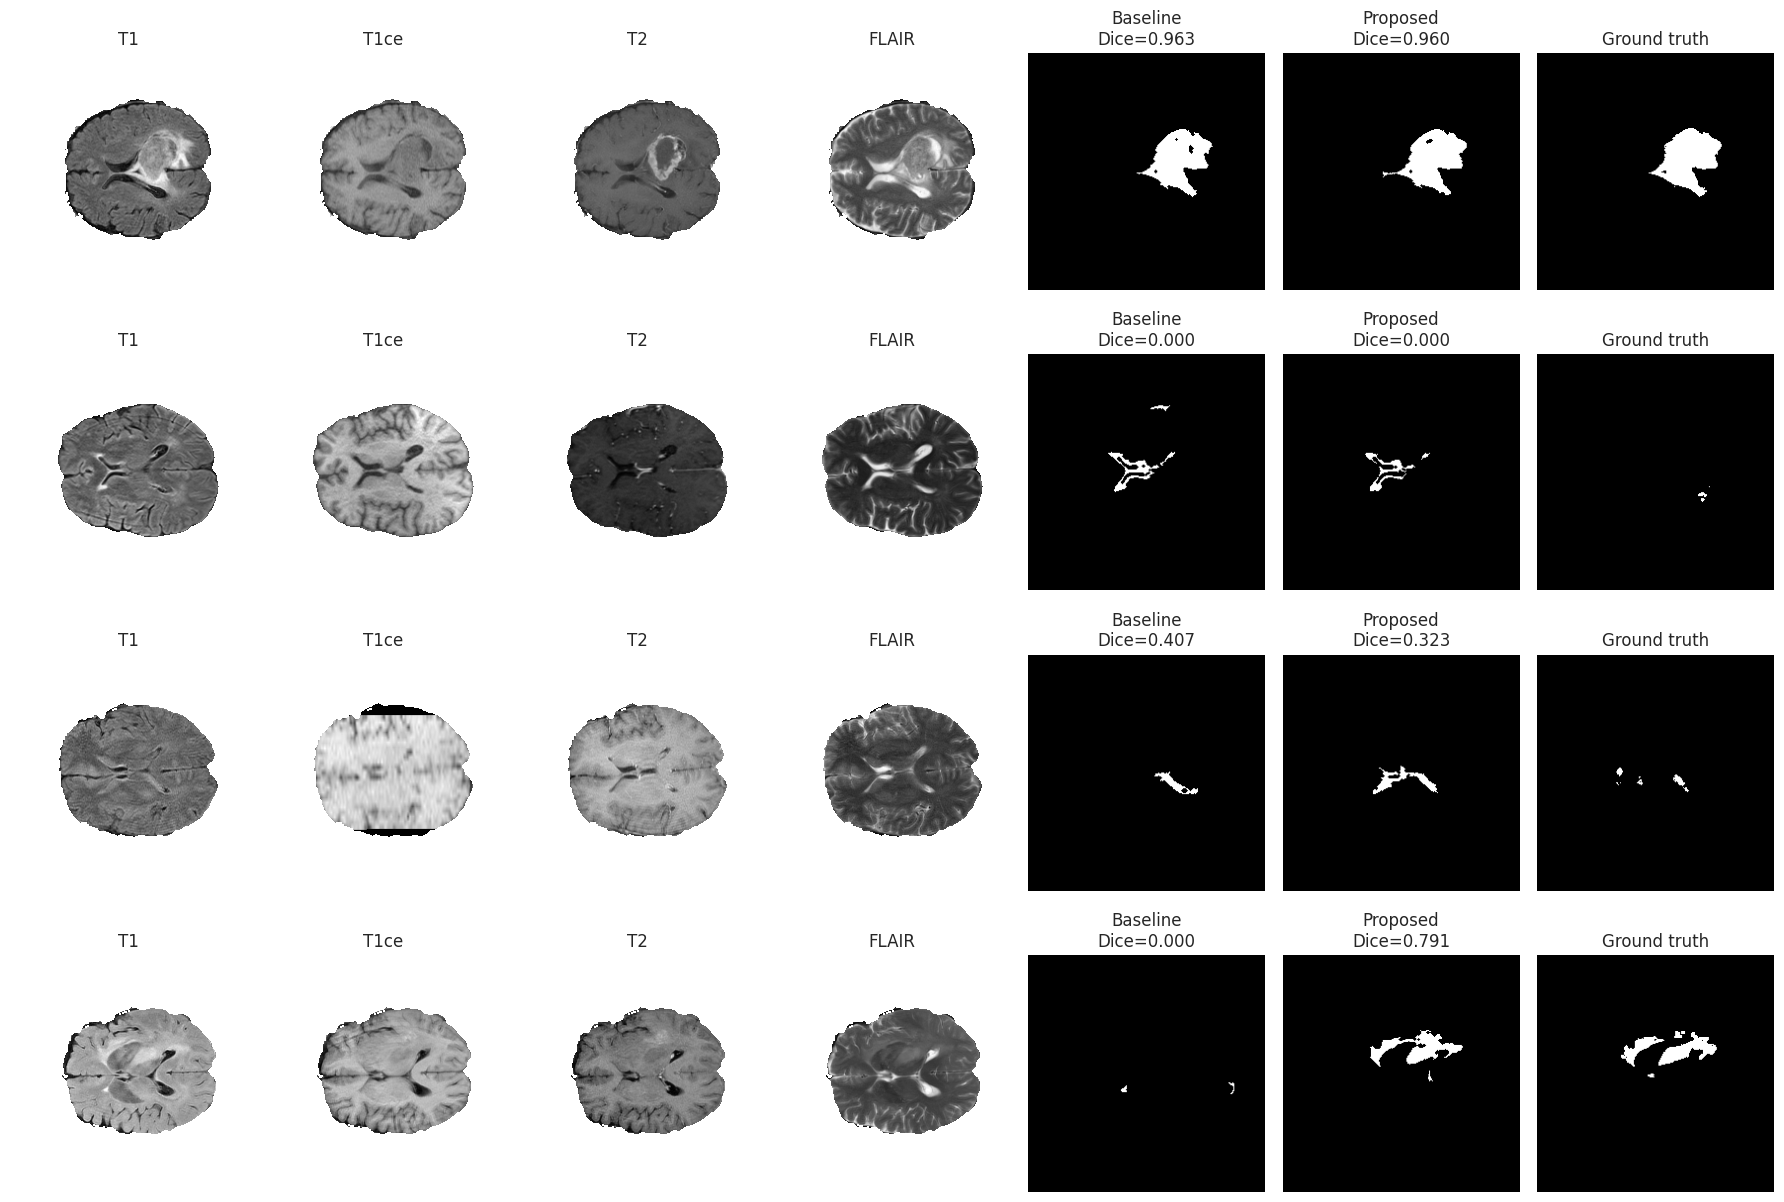

In [22]:
selected_examples = choose_qualitative_examples(
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
)
display(pd.DataFrame(selected_examples.items(), columns=["Required category", "Volume"]))
plot_qualitative_examples(
    selected_examples,
    TEST_RESULTS["Raw (4D)"]["details"],
    TEST_RESULTS["Combined"]["details"],
    FIGURES_DIR / "required_qualitative_examples.png",
)
plt.show()

In [23]:
qualitative_explanations = []
for category, volume_id in selected_examples.items():
    if volume_id is None:
        qualitative_explanations.append({
            "Category": category,
            "Volume": "None",
            "Explanation": "No test case satisfied this requested relationship.",
        })
        continue
    baseline = TEST_RESULTS["Raw (4D)"]["details"][volume_id]
    proposed = TEST_RESULTS["Combined"]["details"][volume_id]
    qualitative_explanations.append({
        "Category": category,
        "Volume": volume_id,
        "Baseline Dice": baseline["dice"],
        "Proposed Dice": proposed["dice"],
        "Explanation": (
            "Interpret the result using tumor size, modality contrast, posterior support, "
            "component acceptance and expansion shown in the diagnostic outputs."
        ),
    })
display(pd.DataFrame(qualitative_explanations).round(4))

,Category,Volume,Baseline Dice,Proposed Dice,Explanation
0,Both performed well,162,0.9630,0.9598,"Interpret the result using tumor size, modalit..."
1,Both performed poorly,102,0.0000,0.0000,"Interpret the result using tumor size, modalit..."
2,Baseline performed better,227,0.4066,0.3234,"Interpret the result using tumor size, modalit..."
3,Proposed model performed better,188,0.0000,0.7908,"Interpret the result using tumor size, modalit..."


## 11. Conclusions and summary

After running the notebook, complete this section using the displayed evidence:

- State whether the combined proposed model outperformed the raw baseline in Dice and IoU.
- Compare Boundary, Symmetry, their direct fusion, and the protected hierarchical final model.
- Explain whether changes were driven by precision, recall, missed tumors, or empty-slice false positives.
- Discuss anatomical plausibility and the roles of FLAIR/T2, T1/T1ce, relative distance and bilateral symmetry.
- Discuss failure cases, validation-test differences and limitations.
- Explicitly note that results are central-slice results and are not directly comparable with full-volume BraTS results.

In [24]:
baseline_summary = TEST_RESULTS["Raw (4D)"]["summary"]
combined_summary = TEST_RESULTS["Combined"]["summary"]
print(f"Baseline mean Dice: {baseline_summary['dice_mean']:.4f}")
print(f"Combined mean Dice: {combined_summary['dice_mean']:.4f}")
print(f"Dice change: {combined_summary['dice_mean'] - baseline_summary['dice_mean']:+.4f}")
print(f"Baseline missed tumors: {baseline_summary['missed_tumors']}")
print(f"Combined missed tumors: {combined_summary['missed_tumors']}")
print(f"Baseline empty-slice false positives: {baseline_summary['empty_slice_false_positives']}")
print(f"Combined empty-slice false positives: {combined_summary['empty_slice_false_positives']}")

Baseline mean Dice: 0.6846
Combined mean Dice: 0.6868
Dice change: +0.0022
Baseline missed tumors: 7
Combined missed tumors: 5
Baseline empty-slice false positives: 4
Combined empty-slice false positives: 6
